# Simulations from Shaer et al. 

## Generate data and perfect sampler

In [7]:
import importlib
import os
os.chdir("c:\\Users\\sebas\\Desktop\\sequential_ml_testing\\src")

import numpy as np
from Sampler import Sampler
import matplotlib.pyplot as plt

def generate_GaussianDirichlet_dataset(n, beta=1.0, d=19, seed=None, U = None, W = None):
    rng = np.random.default_rng(seed)

    # Fixed parameters: IMPORTANT TO NORMALIZE THESE TO KEEP "EFFECT SIZE" FIXED!

    # Correct way of uniformly sampling a convex combination
    if W is None:
        W = np.random.dirichlet(np.ones(d), size=1).flatten()
    if U is None:
        U = np.random.dirichlet(np.ones(d), size=1).flatten()

    # Generate Z ~ N(0, I_d)
    Z = rng.normal(size=(n, d))

    # Generate X | Z ~ N(U^T Z, 1)
    X = Z @ U + rng.normal(size=n)

    # Generate Y
    epsilon = rng.normal(size=n)
    Y = (Z @ W) ** 2 + beta * X + epsilon

    # Design matrix: first column is X, remaining columns are Z
    X_design = np.column_stack((X, Z))

    return X_design, Y, U, W


def generate_FAKE_GaussianDirichlet_dataset(n, beta=1.0, d=19, seed=None, U = None, W = None):
    rng = np.random.default_rng(seed)

    # Fixed parameters: IMPORTANT TO NORMALIZE THESE TO KEEP "EFFECT SIZE" FIXED!

    # Correct way of uniformly sampling a convex combination
    if W is None:
        W = np.random.dirichlet(np.ones(d), size=1).flatten()
    if U is None:
        U = np.random.dirichlet(np.ones(d), size=1).flatten()

    # Generate Z ~ N(0, I_d)
    Z = rng.normal(size=(n, d))

    # Generate X | Z ~ N(U^T Z, 1)
    X = Z @ U + rng.normal(size=n)

    # Generate Y
    epsilon = rng.normal(size=n)
    Y = Z @ W + beta * X + epsilon

    # Design matrix: first column is X, remaining columns are Z
    X_design = np.column_stack((X, Z))

    return X_design, Y, U, W



class GaussianDirichletSampler(Sampler):        ### check I'm getting an error here !!

    def __init__(self, j, U):
            super().__init__(j)
            self.U = U

    def fit(self, X):
        return self

    def sample(self, X):
        if (self.j != 0):
            raise ValueError("GaussianDirichletSampler can only sample for j=0")
        if self.U is None:
            raise ValueError("U must be provided for GaussianDirichletSampler during initialization.")
        
        rng = np.random.default_rng()
        Z = X[:, 1:]  # Extract Z from the design matrix
        X_j = Z @ self.U + rng.normal(size=Z.shape[0])  # Sample X_0 | Z

        return X_j

## Checking learned sampler accuracy

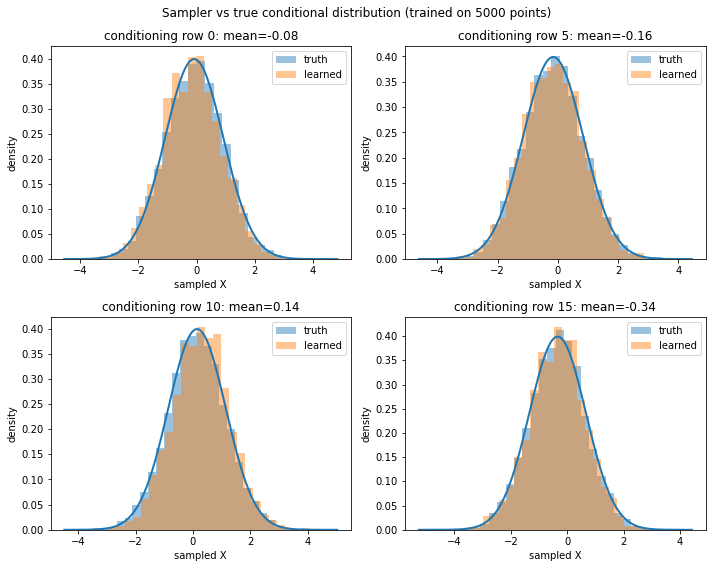

,conditioning_row,mean_error,std_error,ks_stat,ks_p
0,0,-0.081640,-0.011843,0.0458,5.558080e-05
1,5,-0.005942,-0.004064,0.0120,8.643325e-01
2,10,0.121974,-0.016127,0.0630,4.760025e-09
3,15,-0.007468,-0.013602,0.0112,9.124660e-01


In [ ]:
# Checking how many datapoints the kernel estimator needs till it starts to learn the conditional distribution.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, ks_2samp


def generate_GaussianDirichlet_dataset_with_truth(n, beta=1.0, d=19, seed=None, U_true=None, W_true=None):
    rng = np.random.default_rng(seed)

    if U_true is None:
        U_true = np.random.dirichlet(np.ones(d), size=1).flatten()
    if W_true is None:
        W_true = np.random.dirichlet(np.ones(d), size=1).flatten()

    Z = rng.normal(size=(n, d))
    X = Z @ U_true + rng.normal(size=n)
    epsilon = rng.normal(size=n)
    Y = (Z @ W_true) ** 2 + beta * X + epsilon
    X_design = np.column_stack((X, Z))
    return X_design, Y, U_true, W_true


# Train the sampler on a controlled number of points and compare its conditional samples to the truth.
train_n = 5000
eval_n = 300
seed = 7

# Fix the latent truth so the comparison is reproducible.
U_true = np.array([0.08, -0.05, 0.03, 0.01, 0.02, -0.04, 0.06, 0.01, -0.02, 0.04,
                   0.05, -0.03, 0.02, -0.01, 0.03, 0.02, -0.05, 0.04, 0.01])
W_true = np.array([0.04, 0.03, 0.02, 0.01, 0.02, 0.03, 0.06, 0.01, 0.02, 0.03,
                   0.04, 0.02, 0.01, 0.02, 0.03, 0.05, 0.02, 0.01, 0.04])

X_train, Y_train, _, _ = generate_GaussianDirichlet_dataset_with_truth(train_n, beta=0.3, d=19, seed=seed, U_true=U_true, W_true=W_true)
X_eval, Y_eval, _, _ = generate_GaussianDirichlet_dataset_with_truth(eval_n, beta=0.3, d=19, seed=seed + 1, U_true=U_true, W_true=W_true)

sampler = DefaultSampler(j=0)
sampler.fit(X_train)

n_draws = 5000

# Each "row" here means one fixed value of the conditioning variables Z.
# The sampler is asked to generate X values conditional on that same Z.
# We compare the learned samples against the true Gaussian law X | Z ~ N(U^T Z, 1).
conditioning_rows = [0, 5, 10, 15]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False, sharey=False)
axes = axes.ravel()

summary_rows = []
for ax, idx in zip(axes, conditioning_rows):
    row = X_eval[idx:idx + 1]
    z = row[:, 1:]
    true_mean = float(z @ U_true)
    true_std = 1.0

    true_samples = np.random.normal(loc=true_mean, scale=true_std, size=n_draws)

    repeated_row = np.repeat(row, n_draws, axis=0)
    learned_samples = sampler.sample(repeated_row)

    ax.hist(true_samples, bins=25, density=True, alpha=0.45, label="truth", color="tab:blue")
    ax.hist(learned_samples, bins=25, density=True, alpha=0.45, label="learned", color="tab:orange")
    x_grid = np.linspace(min(true_samples.min(), learned_samples.min()) - 1,
                         max(true_samples.max(), learned_samples.max()) + 1, 200)
    ax.plot(x_grid, norm.pdf(x_grid, loc=true_mean, scale=true_std), color="tab:blue", lw=2)
    ax.set_title(f"conditioning row {idx}: mean={true_mean:.2f}")
    ax.set_xlabel("sampled X")
    ax.set_ylabel("density")

    mean_error = float(np.mean(learned_samples) - true_mean)
    std_error = float(np.std(learned_samples) - true_std)
    ks_stat, ks_p = ks_2samp(true_samples, learned_samples)
    summary_rows.append({
        "conditioning_row": idx,
        "mean_error": mean_error,
        "std_error": std_error,
        "ks_stat": ks_stat,
        "ks_p": ks_p,
    })

    ax.legend(loc="best")

fig.suptitle(f"Sampler vs true conditional distribution (trained on {train_n} points)")
fig.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_rows)
summary_df

## Main part - e-process generation and comparison

In [ ]:
import ML_e_process
import AntisymmetricBet
import Sampler
import utils

importlib.reload(utils)
importlib.reload(ML_e_process)
importlib.reload(AntisymmetricBet)
importlib.reload(Sampler)

import numpy as np

from ML_e_process import ML_e_process
from sklearn.linear_model import LassoCV

from ExponentialBet import ExponentialBet  
from AntisymmetricBet import AntisymmetricBet  # adjust import
from Sampler import Sampler,DefaultSampler
from copy import deepcopy
from utils import prepare_exponential_parameters, prepare_coin_betting_parameters, g_family_cb, update_g_func_static, prepare_lambda_parameters, g_family_tanh, g_family_sign
from utils import prepare_kernel_density_parameters, g_family_kde, update_g_func_kernel_density, initialize_kde_history, generate_update_kde
from tqdm import tqdm
import pickle

etas = prepare_exponential_parameters(0.01, 5, 10)
strategy_exp = ExponentialBet(
    parameters=etas,
    exact=True
)


params_cb = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10, M_start = 0.01, M_end = 5, M_num = 10)
strategy_cb = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params_cb,
)


params_tanh = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10)
strategy_tanh = AntisymmetricBet(
    g_family= g_family_tanh, 
    update_g_func = update_g_func_static, 
    parameters=params_tanh,
    prequential=True,
)

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10)

strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=False,
)

strategy_sign_preq = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=True,
)


betting_strategies = {
    "exponential": strategy_exp,
    "coin_betting": strategy_cb,
    "tanh": strategy_tanh,
    "sign": strategy_sign,
    "sign_preq": strategy_sign_preq,

}

### SETTING UP

batch_list = [20]
j_vec = [0]

window_size = None

resamplings_for_betting = 1
resamplings_for_kde = 1 ## best to set this to 1 !! KDE is not learning properly otherwise

learn_conditional_distribution = True  # Does not make a diff for GaussianDirichletSampler, but keep it True for generality.
n_init = 5000
n_total = 5500
used_history_upper_bound = None # bound on the number of used batches, i.e. q-values for the KDE
num_seeds = 10
betas = [0.5] # the standard value was 0.3


updater_kde = generate_update_kde(resamplings_for_kde=resamplings_for_kde, window_size=window_size, used_history_upper_bound=used_history_upper_bound)

bets_js_bs = {
            j: {
                b: {
                    key: deepcopy(strategy)
                    for key, strategy in betting_strategies.items()
                }
                for b in batch_list
            }
            for j in j_vec
        }

### GaussianDirichlet data creation
num_covariates = 3
U = np.random.dirichlet(np.ones(num_covariates), size=1).flatten()
W = np.random.dirichlet(np.ones(num_covariates), size=1).flatten()

sampdoria = [
    GaussianDirichletSampler(j=j, U=U) if j == 0 else DefaultSampler(j=j)
    for j in j_vec
]

### If we want to do multiple betas we need to store the martingales and e_processes for each beta separately.

for beta in betas:
    martingales_per_seed = []
    e_processes_per_seed = []
    for seed in tqdm(range(num_seeds)):
        # GENENRATING DATA 
        X, Y,_,_ = generate_GaussianDirichlet_dataset(n_total, beta=beta, d=num_covariates, seed=seed, U=U, W=W)
        pretraining_qs_dict = initialize_kde_history(
            X[:n_init],
            Y[:n_init].ravel(),
            sampdoria,
            j_vec,
            batch_list,
            model=LassoCV(),
            resamplings_for_kde=resamplings_for_kde,
        )

        for j in j_vec:
            for b in batch_list:
                params_kde = prepare_kernel_density_parameters(kernel_list=["gaussian"],bandwidth_start = 0.05, bandwidth_end = 0.5, bandwidth_num = 3)
                pretraining_qs = pretraining_qs_dict[b][j]

                strategy_kde = AntisymmetricBet(
                    g_family= g_family_kde, 
                    update_g_func = updater_kde, 
                    parameters=params_kde,
                    prequential=True,
                    pretraining_qs = pretraining_qs
                )
                bets_js_bs[j][b]["kde"] = strategy_kde


        e_process = ML_e_process(batch_list=batch_list, n_init=n_init, resamplings_for_betting=resamplings_for_betting, study_j=j_vec,
                        betting_strategies=None, model=LassoCV(),
                        samplers=sampdoria,                                  #### There was a mistake here, should be sampdoria !
                        learn_conditional_distribution=learn_conditional_distribution,
                        optional_stopping=True, 
                        bets_js_bs=bets_js_bs
                        )



        martingales_per_seed.append(e_process.martingales(X, y=Y))
        e_processes_per_seed.append(e_process)


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:24<00:00,  2.43s/it]


Conclusion of the sanity-check slide:
- In the Gaussian-Dirichlet experiment, the setting is perfectly set up for antisymmetric e-variables which are functions of q_tilde-q, since the joint distribution $(q,q_{\tilde})$ seems to satisfy
$q_{\tilde} = aq + b + \varepsilon$, with $a \sim 1$ for some independent random variable $\varepsilon$.\n
 In other words, the density $f(q,q_{\tilde})$ is almost a function of $q_{\tilde}-q$ alone.

24
<class 'tuple'>
<class 'numpy.float64'>
<class 'numpy.ndarray'>
(1,)
U:[0.23029858 0.26495938 0.50474205]
W:[0.25097238 0.22300932 0.52601829]
24
Standard deviation of a: 0.7008480828361067
Standard deviation of b: 0.810157852262714
<class 'tuple'> <class 'tuple'>


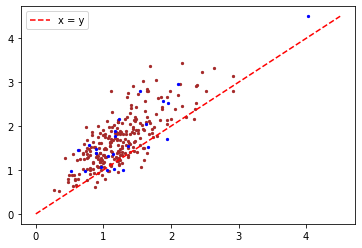

In [43]:
### here we perform SANITY CHECKS, and plot all the observed/generated q,q_tilde pairs
e_process = e_processes_per_seed[2]
pretraining_qs = e_process.bets_js_bs[j_vec[0]][batch_list[0]]['kde'].pretraining_qs
past_qs = e_process.bets_js_bs[j_vec[0]][batch_list[0]]['kde'].past_qs
print(len(past_qs))
print(type(past_qs[0]))
print(type(past_qs[0][0]))
print(type(past_qs[0][1]))
print(past_qs[0][1].shape)  # exactly equal to resamplings_for_kde
print(f"U:{U}")
print(f"W:{W}")
history = []
for i in range(len(past_qs)):
    for j in range(len(past_qs[i][1])):
        history.append(tuple([past_qs[i][0], past_qs[i][1][j]]))

# combine with pretraining data
a,b = zip(*history)
print(len(b))
print(f"Standard deviation of a: {np.std(a)}")
print(f"Standard deviation of b: {np.std(b)}")
print(type(a), type(b))
pretraining_boundary = resamplings_for_kde*n_init//batch_list[0]

def plot_q_qtilde(a,b,pretraining_boundary):
    #plt.scatter(a[0:pretraining_boundary],b[0:pretraining_boundary], color = 'brown', marker='o', s=5)
    #plt.scatter(a[pretraining_boundary:],b[pretraining_boundary:], color = 'blue', marker='o', s=5)
    plt.scatter(pretraining_qs[:,0],pretraining_qs[:,1], color = 'brown', marker='o', s=5)
    plt.scatter(a,b, color = 'blue', marker='o', s=5)
    plt.plot([0, max(a+b)], [0, max(a+b)], 'r--', label='x = y')
    plt.plot()
    plt.legend()
    plt.show()

plot_q_qtilde(a,b,pretraining_boundary)

In [44]:
### What is the optimal kde bandwidth based on the data
for i in range(len(e_processes_per_seed)):
    e_process = e_processes_per_seed[i]
    best_kde_parameters_index = np.argmax(e_process.bets_js_bs[j_vec[0]][batch_list[0]]['kde'].past_martingales)
    print(f"Best KDE parameters index: {best_kde_parameters_index}")
    print(f"Best KDE parameters: {e_process.bets_js_bs[j_vec[0]][batch_list[0]]['kde'].parameters[best_kde_parameters_index]}")

Best KDE parameters index: 1
Best KDE parameters: {'kernel': 'gaussian', 'bandwidth': 0.275}
Best KDE parameters index: 1
Best KDE parameters: {'kernel': 'gaussian', 'bandwidth': 0.275}
Best KDE parameters index: 1
Best KDE parameters: {'kernel': 'gaussian', 'bandwidth': 0.275}
Best KDE parameters index: 1
Best KDE parameters: {'kernel': 'gaussian', 'bandwidth': 0.275}
Best KDE parameters index: 1
Best KDE parameters: {'kernel': 'gaussian', 'bandwidth': 0.275}
Best KDE parameters index: 1
Best KDE parameters: {'kernel': 'gaussian', 'bandwidth': 0.275}
Best KDE parameters index: 1
Best KDE parameters: {'kernel': 'gaussian', 'bandwidth': 0.275}
Best KDE parameters index: 1
Best KDE parameters: {'kernel': 'gaussian', 'bandwidth': 0.275}
Best KDE parameters index: 1
Best KDE parameters: {'kernel': 'gaussian', 'bandwidth': 0.275}
Best KDE parameters index: 1
Best KDE parameters: {'kernel': 'gaussian', 'bandwidth': 0.275}


CONCLUSIONS SO FAR: 
- The reason why KDE starts good and then becomes worse is not an implementation issue,its because of a very small bandwidth chosen by preq plug-in! After enough time KDE observes an OOD sample and e-process drops to a very low value. Since we avg over seeds we don't notice the big drops that happen in speciffic seeds !!!
- A setting where KDE works very well is no Rao blackewellization, min_bandwidth = 0.2, large pretraining set and around 500//20 bets, and beta = 1 !!
- Possible reason why sign and cb are so good: the dataset is too simple, and the regression kernel approximates the truth. If this was not the case maybe CB and sign would become worse, but KDE could still improve based on its flexibility! Maybe the distribution of (q,q_tilde) is too simple with this dataset, and KDE can not make use of the additional flexibility, but still has to pay for it!
- If we set resamplings_for_betting = 1, antisymmetric e-vars (KDE and CB, sign_preq) perform close to exponential BUT the exponential profits much more from Rao-Blackwellization!

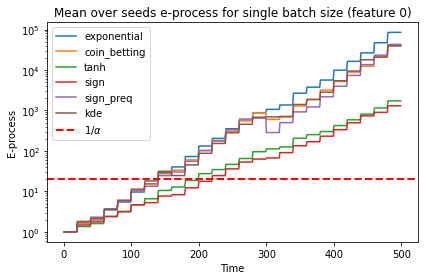

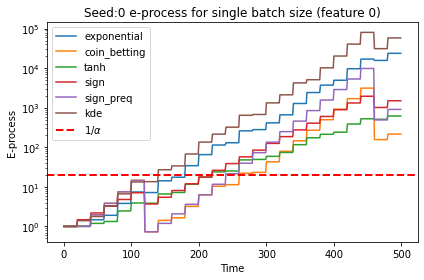

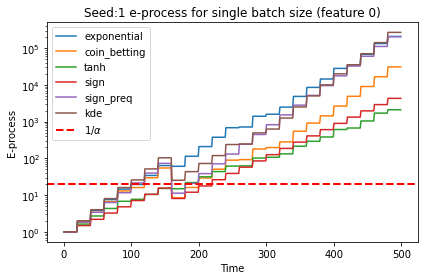

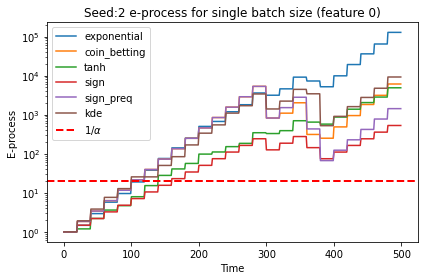

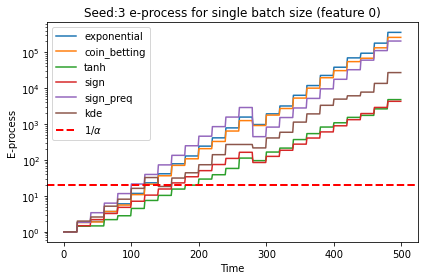

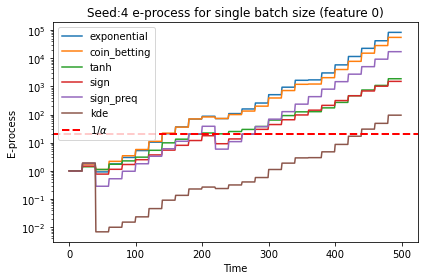

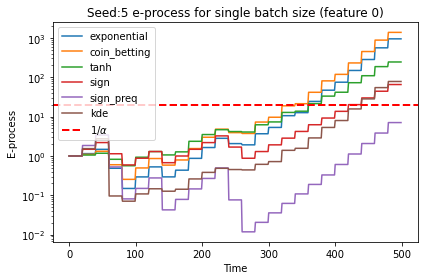

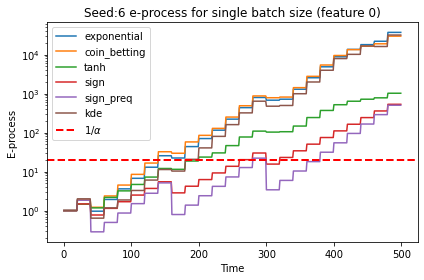

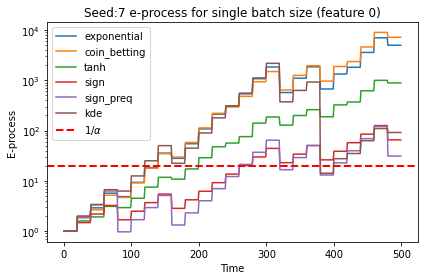

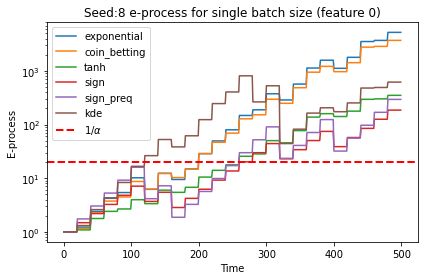

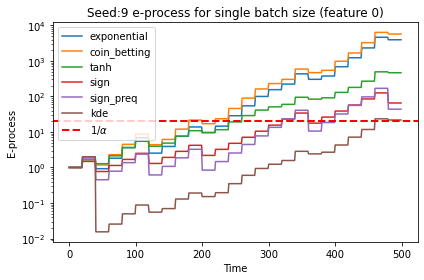

In [45]:
import matplotlib.pyplot as plt
alpha = 0.05

#martingales = martingales_per_seed[9]

plt.figure(figsize=(6, 4))
j=0
batch_size = batch_list[0] 

strategy_names = ['exponential','coin_betting','tanh','sign','sign_preq','kde']
antisymmetric_strategy_names = ['coin_betting','tanh','sign','sign_preq','kde']

for strategy_name in strategy_names:
    # average over seeds
    plt.plot(np.mean([martingales_per_seed[i][strategy_name][batch_size][j][n_init:] for i in range(num_seeds)],axis=0), label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean over seeds e-process for single batch size (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()

for i in range(num_seeds):
    for strategy_name in strategy_names:
        plt.plot(martingales_per_seed[i][strategy_name][batch_size][j][n_init:], label=strategy_name)

        # tab backwards later
    plt.axhline(
        y=1 / alpha,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$1/\alpha$"
    )

    plt.yscale("log")
    plt.xlabel("Time")
    plt.ylabel("E-process")
    plt.title(f"Seed:{i} e-process for single batch size (feature {j})")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Non-linear models (possibly skip this completely)

We need more complex models

In [9]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor


e_process_gb = ML_e_process(batch_list=batch_list, n_init=50, b_resamplings=20, study_j=j_vec,
                 betting_strategies=betting_strategies, model=GradientBoostingRegressor(),
                 #learn_conditional_distribution=get_data_statistics,
                 samplers=None, #sampling_args={}
                 learn_conditional_distribution=True,
                 optional_stopping=True, 
                 )

In [10]:
martingales_gb = e_process_gb.martingales(X, y=Y)

/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), 

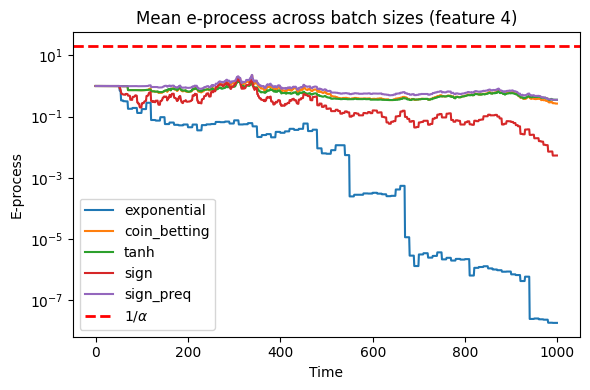

In [24]:
j = 4
plt.figure(figsize=(6, 4))

for strategy_name in betting_strategies.keys():
    mean_process = np.mean(
        [martingales_gb[strategy_name][b][j] for b in batch_list],
        axis=0
    )

    plt.plot(mean_process, label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean e-process across batch sizes (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()